#Identificação de Perfis de Consumidores via Matriz RFM e Clustering

Este projeto aplica técnicas de Clusterização integradas à Matriz RFM (Recência, Frequência, Valor Monetário) para segmentar uma base de clientes de acordo com seus comportamentos de consumo.

O objetivo é agrupar consumidores com características similares em clusters homogêneos, permitindo a extração de insights estratégicos e a personalização de ações de marketing. A metodologia utiliza três pilares fundamentais:

**Recência (R)**: Tempo decorrido desde a última compra.

**Frequência (F)**: Quantidade total de transações realizadas no período.

**Valor Monetário (M)**: Volume financeiro total gerado pelo cliente.

A união do algoritmo K-Means com a Matriz RFM permite uma análise multidimensional que vai além de métricas simples, identificando padrões complexos de lealdade e rentabilidade.

Foram utilizadas as planilhas CLIENTES, VENDAS e VENDAS_PRODUTOS para realizar o trabalho.

In [ ]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'colab'

In [ ]:
# Upload das planilhas
vendas = pd.read_csv('VENDAS.csv', delimiter=';')
vendas_produtos = pd.read_csv('VENDAS_PRODUTOS.csv', decimal=',', thousands='.', delimiter=';')
clientes = pd.read_csv('CLIENTES.csv', delimiter=';')

In [ ]:
# Junção das planilhas
df_unificada1 = pd.merge(
    vendas_produtos,
    vendas,
    on='ID_VENDA',
    how='left'
)

df_unificada1.head()

,ID_VENDA,ID_PRODUTO,QUANTIDADE,VALOR_UNITARIO_VENDA_PRODUTO,VALOR_VENDA_PRODUTO,DATA_VENDA,ID_FILIAL,ID_CLIENTE,VALOR_VENDA
0,1,6,1,150.0,150.0,01/10/2023,1,1456,"150,00"
1,2,20,2,24.5,49.0,02/10/2023,1,527,"521,80"
2,2,2,2,120.0,240.0,02/10/2023,1,527,"521,80"
3,2,10,3,77.6,232.8,02/10/2023,1,527,"521,80"
4,3,6,1,147.0,147.0,02/10/2023,1,1564,"147,00"


In [ ]:
# Junção das planilhas
df_unificada = pd.merge(
    df_unificada1,
    clientes,
    on='ID_CLIENTE',
    how='left'
)

df_unificada.head()

,ID_VENDA,ID_PRODUTO,QUANTIDADE,VALOR_UNITARIO_VENDA_PRODUTO,VALOR_VENDA_PRODUTO,DATA_VENDA,ID_FILIAL,ID_CLIENTE,VALOR_VENDA,NOME_CLIENTE,CIDADE,UF
0,1,6,1,150.0,150.0,01/10/2023,1,1456,"150,00",MARIA ASSAD MORAIS,CURITIBA,PR
1,2,20,2,24.5,49.0,02/10/2023,1,527,"521,80",ISABELA ARAUJO RIBEIRO MELO,CURITIBA,PR
2,2,2,2,120.0,240.0,02/10/2023,1,527,"521,80",ISABELA ARAUJO RIBEIRO MELO,CURITIBA,PR
3,2,10,3,77.6,232.8,02/10/2023,1,527,"521,80",ISABELA ARAUJO RIBEIRO MELO,CURITIBA,PR
4,3,6,1,147.0,147.0,02/10/2023,1,1564,"147,00",MARCIA TAVARES SOUZA,CURITIBA,PR


In [ ]:
# Alterando tipo das variáveis
for col in ['QUANTIDADE', 'VALOR_VENDA_PRODUTO', 'VALOR_VENDA']:
    df_unificada[col] = df_unificada[col].astype(str).str.replace(',', '.', regex=False)
    df_unificada[col] = pd.to_numeric(df_unificada[col], errors='coerce')

In [ ]:
# Conferindo valor de venda total
faturamento_total = df_unificada['VALOR_VENDA_PRODUTO'].sum()
print(f"Faturamento total: {faturamento_total:.2f}")

Faturamento total: 4398079.30


In [ ]:
df_trabalho = df_unificada.copy()

# Correção Data
df_trabalho['DATA_VENDA'] = pd.to_datetime(df_trabalho['DATA_VENDA'], dayfirst=True)

# Criar Dummies das cidades e UFs
df_dummies = pd.get_dummies(df_trabalho, columns=['CIDADE', 'UF'], dtype=int)

In [ ]:
# Criação dos dados da Matriz RFM

# Data de referência
data_ref = df_dummies['DATA_VENDA'].max() + pd.Timedelta(days=1)

# Identificar todas as colunas de cidade/uf
colunas_estados_uf = [col for col in df_dummies.columns if 'UF_' in col or 'CIDADE_' in col]

# Definir regras da matriz
regras = {
    'DATA_VENDA': lambda x: (data_ref - x.max()).days, # RECÊNCIA
    'ID_VENDA': 'nunique',                             # FREQUÊNCIA
    'VALOR_VENDA_PRODUTO': 'sum',                      # MONETÁRIO
}


for col in colunas_estados_uf:
    regras[col] = 'max'

# Agrupar por Cliente
df_clientes = df_dummies.groupby('ID_CLIENTE').agg(regras).reset_index()

# Renomear as colunas
df_clientes.rename(columns={
    'DATA_VENDA': 'Recencia',
    'ID_VENDA': 'Frequencia',
    'VALOR_VENDA_PRODUTO': 'Monetario'
}, inplace=True)

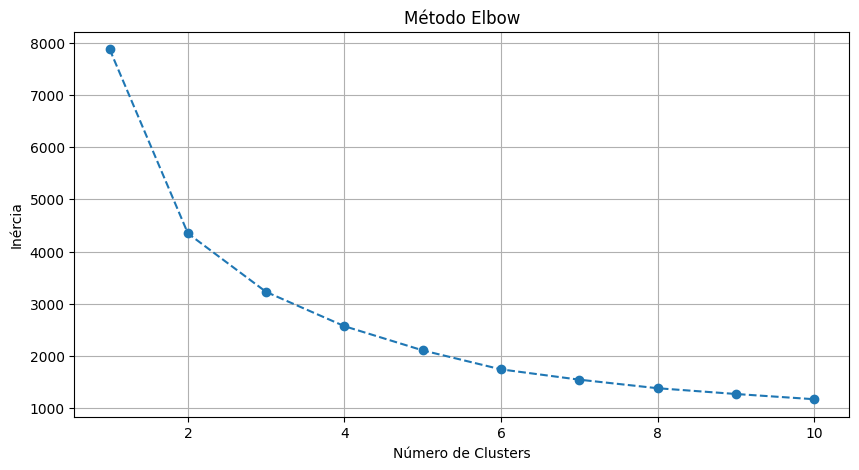


RESUMO DOS PERFIS


Cluster,0,1,2
Recencia,39.313622,14.492857,5.535885
Frequencia,1.414995,3.240476,10.949761
Monetario,483.182735,1501.692222,4900.413995
CIDADE_ARAUCARIA,0.024287,0.025397,0.043062
CIDADE_BALNEARIO CAMBORIU,0.002112,0.002381,0.007177
CIDADE_BLUMENAU,0.005280,0.011111,0.021531
CIDADE_BRUSQUE,0.002112,0.000000,0.004785
CIDADE_CAMPO LARGO,0.038015,0.032540,0.028708
CIDADE_CASTRO,0.011616,0.008730,0.014354
CIDADE_CURITIBA,0.766631,0.782540,0.753589


In [ ]:
# CLUSTER

cols_foco = ['Recencia', 'Frequencia', 'Monetario']
df_foco = df_clientes[cols_foco].copy()

# Aplicar Logaritmo para melhorar os dados
df_log = df_foco.apply(np.log1p)

# Padronizar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)


# Método Elbow para analisar o melhor número de clusters
elbow = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='random', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    elbow.append(kmeans.inertia_)

# Gráfico do método Elbow
plt.figure(figsize=(10, 5))
plt.plot(K_range, elbow, marker='o', linestyle='--')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método Elbow')
plt.grid(True)
plt.show()

# Número de Clusters
n_clusters = 3

# Rodar K-Means Final
kmeans_final = KMeans(n_clusters=n_clusters, init='random', random_state=23, n_init=10)
kmeans_final.fit(df_scaled)

# Colocar o resultado de volta na tabela
df_clientes['Cluster'] = kmeans_final.labels_

# Remover ID_CLIENTE
df_analise = df_clientes.drop(columns=['ID_CLIENTE'])

# Agrupar por cluster
resumo = df_analise.groupby('Cluster').mean()

# Adicionar contagem
resumo['Qtd_Pessoas'] = df_clientes['Cluster'].value_counts()

print("\nRESUMO DOS PERFIS")
display(resumo.T)

In [ ]:
# Criação tabela com os clientes e seus clusters/perfil.

df_pre_final = df_unificada[['ID_CLIENTE', 'NOME_CLIENTE', 'CIDADE', 'UF']].drop_duplicates('ID_CLIENTE')

# Juntar com a tabela de Clusters
df_final = df_pre_final.merge(df_clientes[['ID_CLIENTE', 'Cluster', 'Recencia', 'Frequencia', 'Monetario']],
                                 on='ID_CLIENTE',
                                 how='inner')

# Nomeando os clusters
# Cluster 2 = VIP / Elite (Gasta muito)
# Cluster 0 = Ocasional (Gasta pouco/ Baixa frequência)
# Cluster 1 = Fiel / Recorrente (Gasta médio)

def nomear_grupo(cluster_num):
    if cluster_num == 2: return 'VIP / Elite'
    if cluster_num == 0: return 'Ocasional'
    if cluster_num == 1: return 'Recorrente / Fiel'
    return 'Outros'

df_final['Perfil'] = df_final['Cluster'].apply(nomear_grupo)

df_final = df_final[['ID_CLIENTE', 'NOME_CLIENTE', 'Perfil', 'Recencia', 'Frequencia', 'Monetario', 'CIDADE', 'UF']]

print("Amostra da Lista final")
display(df_final.head(10))

# Gera arquivo final em Excel
df_final.to_excel("Lista_Segmentada_Clientes.xlsx", index=False)

Amostra da Lista final


,ID_CLIENTE,NOME_CLIENTE,Perfil,Recencia,Frequencia,Monetario,CIDADE,UF
0,1456,MARIA ASSAD MORAIS,Ocasional,8,2,270.00,CURITIBA,PR
1,527,ISABELA ARAUJO RIBEIRO MELO,VIP / Elite,1,8,3010.45,CURITIBA,PR
2,1564,MARCIA TAVARES SOUZA,Recorrente / Fiel,15,2,711.30,CURITIBA,PR
3,1079,MARIANA PESSOA COELHO TOLEDO,Ocasional,33,2,928.70,CURITIBA,PR
4,1015,FLAVIA BARRETO PIRES,VIP / Elite,3,10,5227.30,CURITIBA,PR
5,255,DIOGO MARQUES,VIP / Elite,2,6,1305.50,CURITIBA,PR
6,1524,VITORIA RODRIGUES ESCOBAR,VIP / Elite,10,7,4412.95,CURITIBA,PR
7,1800,PAULO OLIVEIRA,Recorrente / Fiel,2,4,1398.30,CURITIBA,PR
8,1411,ROSANA SIQUEIRA,Recorrente / Fiel,9,4,1124.20,JOINVILLE,SC
9,100,CLAUDIO FEITOSA BORBA SEVERO,VIP / Elite,4,23,9904.20,CURITIBA,PR


In [ ]:
# Participação de cada grupo no faturamento
soma_monetario_por_perfil = df_final.groupby('Perfil')['Monetario'].sum()

print("Soma total do valor Monetário para cada perfil de cliente:")
display(soma_monetario_por_perfil)

Soma total do valor Monetário para cada perfil de cliente:


,Monetario
Perfil,
Ocasional,457574.05
Recorrente / Fiel,1892132.20
VIP / Elite,2048373.05


#Conclusão e Segmentação Estratégica
O objetivo deste projeto foi transformar dados transacionais em inteligência de negócio através da metodologia RFM e do algoritmo K-Means. Para garantir o rigor estatístico, o pipeline aplicou normalização de escala e transformação logarítmica, mitigando o impacto de variância e outliers.

###Perfis de Consumo
**VIP / Elite** (418 clientes): É o grupo com o menor número de integrantes, porém com a maior frequência de compra e valor monetário individual. A estratégia recomendada é a retenção e exclusividade, visando proteger este faturamento de alto nível com atendimento e benefícios personalizados.

**Recorrente / Fiel** (1.260 clientes): O grupo mais numeroso da base, caracterizado por comprar volumes maiores em valor e com frequência superior ao perfil ocasional. O foco estratégico é a rentabilização, buscando aumentar o ticket médio através de ofertas complementares (cross-selling) e programas de fidelidade.

**Ocasional** (947 clientes): Consumidores que apresentam gasto e frequência de compra inferiores aos demais grupos. Representam um risco real de abandono (churn), e a tática sugerida é a reativação, utilizando campanhas de desconto agressivas para reinseri-los no ciclo de consumo.

Impacto no Faturamento: A análise demonstrou que a união dos grupos VIP e Fiel concentra aproximadamente 89% do faturamento total, validando o alto ROI em estratégias de fidelização e manutenção desses perfis.